FOLLOWING THE CRISPDM METHOD
1. BUSINESS UNDERSTANDING
2. METRIC OF SUCCESS
3. DATA UNDERSTANDING
4. DATA PREPARATION( data cleaning, feature engineering), EDA
5. MODELLING
6. EVALUATION
7. DEPLOYEMENT

### BUSINESS UNDERSTANDING
Customer churn is a critical challenge in the telecommunications industry. When customers discontinue their services, the company not only loses recurring revenue but also incurs additional costs associated with acquiring new customers. Since retaining an existing customer is generally more cost-effective than acquiring a new one, proactively identifying customers who are likely to churn is essential for sustainable growth and profitability.

The objective of this project is to develop a predictive model that can accurately determine whether a customer is likely to leave the company. This is a binary classification problem, where the outcome variable indicates either churn (customer leaves) or no churn (customer stays). Beyond prediction accuracy, understanding the key factors that drive churn is equally important. Insights into these drivers enable the business to design targeted retention strategies such as personalized offers, service improvements, or customer engagement initiatives.

### Business Problem

The company lacks a reliable, data-driven method to identify customers at high risk of churning. As a result, retention efforts may be reactive rather than proactive, leading to revenue loss and inefficient use of marketing resources.

## Business Objectives

Predict the likelihood of customer churn with high accuracy.

Identify the most significant factors influencing churn behavior.

Enable the company to implement targeted retention strategies.

Reduce customer attrition and improve overall customer lifetime value.

## Stakeholders

Marketing Team – To design targeted retention campaigns.

Customer Service Team – To proactively engage high-risk customers.

Management/Executives – To make strategic decisions based on churn insights.

Data Team – To monitor and improve predictive performance over time.

## metrics of success
The project is successful if:

The model achieves high recall (e.g., >80%) for churners.

It maintains reasonable precision to avoid excessive false positives.

The company experiences a measurable reduction in churn rate.

Retention efforts generate a positive return on investment (ROI).


### import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### DATA UNDERSTANDING

In [2]:
df = pd.read_csv('syriatel.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [4]:
# check for duplicates
df.duplicated().sum()

0

In [5]:
# check for class distribution
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)

churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64

In [6]:
# Explore Categorical Variables
df['international plan'].value_counts()
df['voice mail plan'].value_counts()
df['state'].value_counts()

state
WV    106
MN     84
NY     83
AL     80
WI     78
OH     78
OR     78
WY     77
VA     77
CT     74
MI     73
ID     73
VT     73
TX     72
UT     72
IN     71
MD     70
KS     70
NC     68
NJ     68
MT     68
CO     66
NV     66
WA     66
RI     65
MA     65
MS     65
AZ     64
FL     63
MO     63
NM     62
ME     62
ND     62
NE     61
OK     61
DE     61
SC     60
SD     60
KY     59
IL     58
NH     56
AR     55
GA     54
DC     54
HI     53
TN     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [7]:
# Explore Relationships with Churn
pd.crosstab(df['international plan'], df['churn'])
pd.crosstab(df['voice mail plan'], df['churn'])
pd.crosstab(df['customer service calls'], df['churn'])

churn,False,True
customer service calls,,
0,605,92
1,1059,122
2,672,87
3,385,44
4,90,76
5,26,40
6,8,14
7,4,5
8,1,1


The dataset contains 3,333 customer records with 20 features describing customer demographics, service usage patterns, and subscription details. The target variable, churn, indicates whether a customer discontinued the service (True) or remained active (False).

There are no missing values in the dataset, and no duplicate records were identified. The dataset consists of a mix of numerical features (e.g., total day minutes, total charges, number of calls) and categorical features (e.g., state, international plan, voice mail plan).

Preliminary exploration shows that the dataset is moderately imbalanced, with a significantly higher proportion of non-churn customers compared to churn customers. Initial cross-tabulation analysis suggests that customers with international plans and those who frequently contact customer service are more likely to churn.

### DATA PREPARATION

In [8]:
# Drop irrelevant columns like phone number since that is just an ID
df.drop('phone number', axis=1, inplace=True)

In [9]:
# Convert Yes/No to Binary
df['international plan'] = df['international plan'].map({'yes':1, 'no':0})
df['voice mail plan'] = df['voice mail plan'].map({'yes':1, 'no':0})

In [10]:
# Convert Target to Binary 
df['churn'] = df['churn'].astype(int)

In [11]:
# Encode State
df = pd.get_dummies(df, columns=['state'], drop_first=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 69 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   area code               3333 non-null   int64  
 2   international plan      3333 non-null   int64  
 3   voice mail plan         3333 non-null   int64  
 4   number vmail messages   3333 non-null   int64  
 5   total day minutes       3333 non-null   float64
 6   total day calls         3333 non-null   int64  
 7   total day charge        3333 non-null   float64
 8   total eve minutes       3333 non-null   float64
 9   total eve calls         3333 non-null   int64  
 10  total eve charge        3333 non-null   float64
 11  total night minutes     3333 non-null   float64
 12  total night calls       3333 non-null   int64  
 13  total night charge      3333 non-null   float64
 14  total intl minutes      3333 non-null   

Data preparation involved cleaning and transforming the dataset to make it suitable for modeling. Duplicate records were checked and none were found. The phone number column was removed as it serves only as a unique identifier and does not contribute to predictive power.

Categorical variables such as international plan and voice mail plan were encoded into binary numerical format. The target variable churn was also converted into binary form for classification modeling. Feature encoding and scaling were performed where necessary to ensure compatibility with machine learning algorithms.

In [13]:
df.to_csv("churn_cleaned.csv", index=False)

## Reload the Cleaned Dataset

In [16]:
df = pd.read_csv("churn_cleaned.csv")
df
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 69 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   area code               3333 non-null   int64  
 2   international plan      3333 non-null   int64  
 3   voice mail plan         3333 non-null   int64  
 4   number vmail messages   3333 non-null   int64  
 5   total day minutes       3333 non-null   float64
 6   total day calls         3333 non-null   int64  
 7   total day charge        3333 non-null   float64
 8   total eve minutes       3333 non-null   float64
 9   total eve calls         3333 non-null   int64  
 10  total eve charge        3333 non-null   float64
 11  total night minutes     3333 non-null   float64
 12  total night calls       3333 non-null   int64  
 13  total night charge      3333 non-null   float64
 14  total intl minutes      3333 non-null   

lets drop all the charge columns since these perfectly correlated with minutes therefore may create multicollinearity , redundant features

In [17]:
df.drop([
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
], axis=1, inplace=True)

In [20]:
df.drop('state_AL', axis=1, inplace=True)

To avoid multicollinearity caused by one-hot encoding all state categories, the drop_first=True parameter was used to remove one reference category and prevent the dummy variable trap.

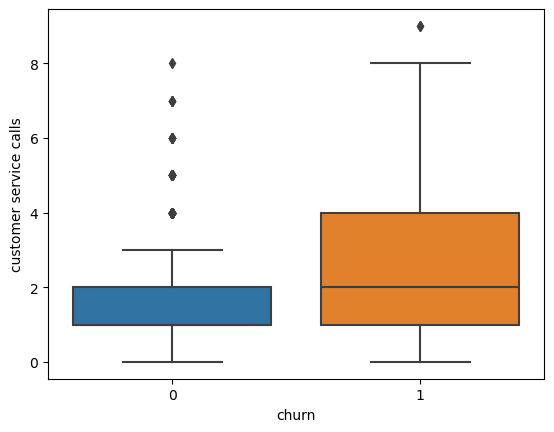

In [21]:
sns.boxplot(x='churn', y='customer service calls', data=df)
plt.show()

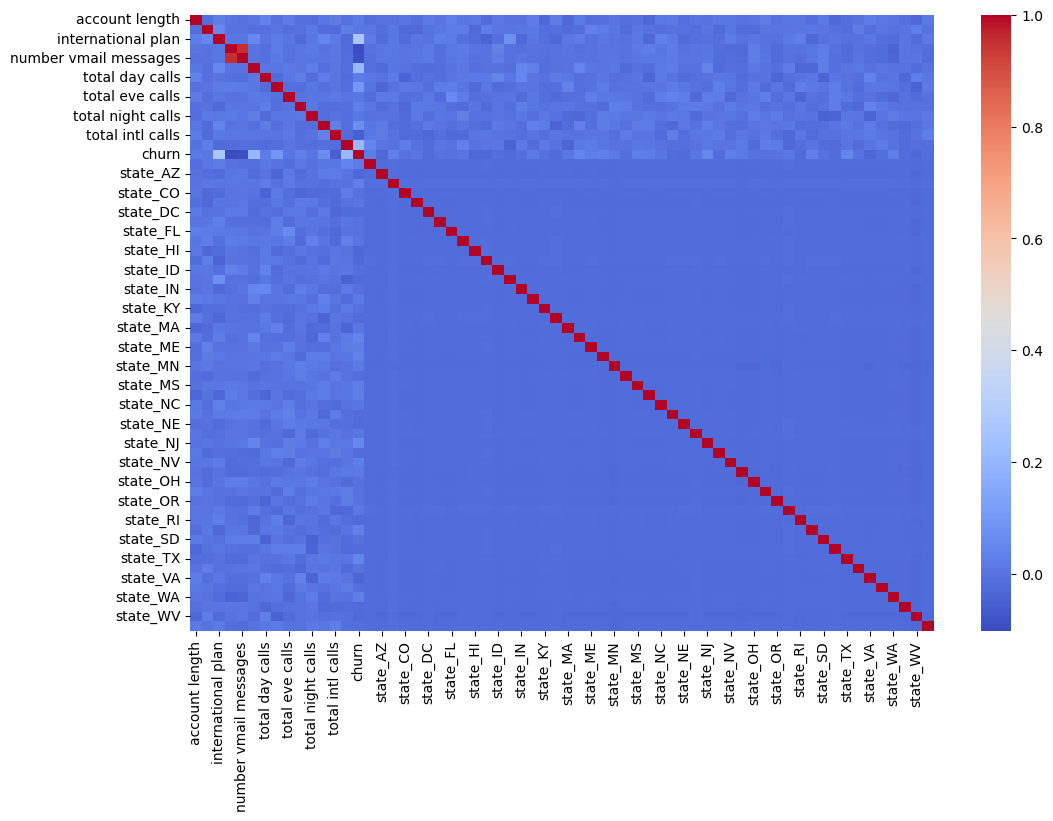

In [22]:
#correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

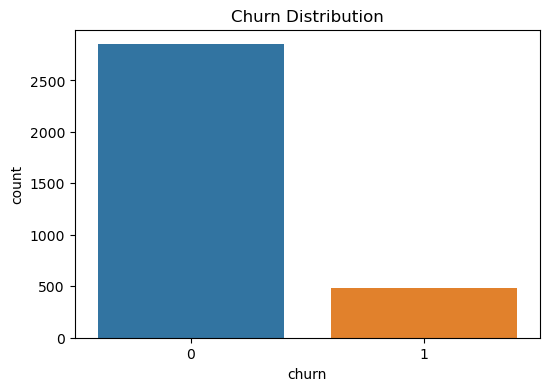

In [23]:
# churn distribution

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

AttributeError: 'numpy.int64' object has no attribute 'startswith'

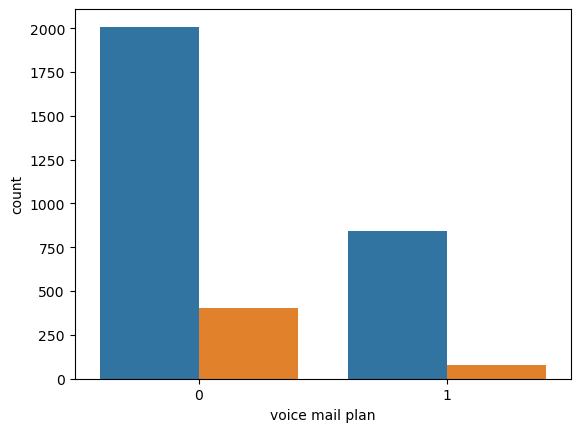

In [25]:
# churn vs voice mail plan
sns.countplot(x='voice mail plan', hue='churn', data=df)
plt.title('Churn vs Voice Mail Plan')
plt.show()